In [13]:
import sys
import os

running_path = "/Odyssey/private/o23gauvr/code/"
os.chdir(running_path)
sys.path.insert(0,running_path)
sys.path.insert(0, "/Odyssey/private/o23gauvr/code/FASCINATION")


from sklearn.decomposition import PCA
from FASCINATION.src.utils import unorm_ssp_arr_3D

import numpy as np
from scipy.ndimage import convolve
import matplotlib.pyplot as plt

import math
import torch
import pickle


# Functions

In [14]:


def parse_experiment_config(ckpt_path):
    """
    Parse experiment_config.log file to extract N and M values.
    
    Args:
        ckpt_path (str): PosixPath to checkpoint 
        
    Returns:
        tuple: (N, M) values or (None, None) if parsing fails
    """

    config_file = list((ckpt_path.parent.parent).rglob("train_*.log")) 
    if not config_file:
        print(f"Warning: train logs not found in {ckpt_path}")
        return None, None
    
    config_file = config_file[0]  # Get the first match if multiple found

    try:
        with open(config_file, 'r') as f:
            content = f.read()
        
        # Extract N and M values from MODEL CONFIGURATION section
        N, M = None, None
        
        lines = content.split('\n')

        cfg = eval((lines[1].strip().split("INFO: ")[-1]).replace("<class 'torch.nn.modules.activation.","nn.").replace("'>",""))


        return cfg
        
            
    except Exception as e:
        print(f"Error parsing config file in {ckpt_path}: {e}")
        return None




In [15]:


def get_min_max_idx(arr: np.ndarray, axs: int = 1, pad: bool = True) -> np.ndarray:
    grad = np.diff(arr, axis=axs)
    grad_sign = np.sign(grad)
    min_max = np.abs(np.sign(np.diff(grad_sign, axis=axs)))
    if pad:
        # pad for 4D arrays (t, z, lat, lon)
        pad_width = [(0, 0)] * arr.ndim
        pad_width[axs] = (1, 1)
        min_max = np.pad(min_max, pad_width, 'constant', constant_values=1)
    return min_max


def get_f1_score(min_max_idx_truth: np.ndarray, min_max_idx_ae: np.ndarray, axs: int = 1, kernel_size: int = 10) -> np.ndarray:
    kernel_shape = [1] * min_max_idx_truth.ndim
    kernel_shape[axs] = kernel_size
    kernel = np.ones(kernel_shape)
    truth_expanded = convolve(min_max_idx_truth, kernel, mode='constant', cval=0.0)
    ae_expanded = convolve(min_max_idx_ae, kernel, mode='constant', cval=0.0)
    true_positives = (truth_expanded > 0) & (min_max_idx_ae > 0)
    num_true_positives = np.sum(true_positives, axis=axs)
    false_positives = (truth_expanded == 0) & (min_max_idx_ae > 0)
    num_false_positives = np.sum(false_positives, axis=axs)
    false_negatives = (min_max_idx_truth > 0) & (ae_expanded == 0)
    num_false_negatives = np.sum(false_negatives, axis=axs)
    precision_den = num_true_positives + num_false_positives
    recall_den = num_true_positives + num_false_negatives
    precision_score = np.where(precision_den == 0, 0, num_true_positives / precision_den)
    recall_score = np.where(recall_den == 0, 0, num_true_positives / recall_den)
    sum_scores = precision_score + recall_score
    f1_score = np.where(sum_scores == 0, 0, 2 * (precision_score * recall_score) / sum_scores)
    return f1_score


In [16]:
def compute_total_bits(out_net) -> float:
    return sum(torch.log(likelihoods).sum() / (-math.log(2)) for likelihoods in out_net['likelihoods'].values()).item()



def compute_bpe(out_net, num_pixels) -> float:
    return sum(
        (torch.log(likelihoods).sum() / (-math.log(2) * num_pixels))
        for likelihoods in out_net["likelihoods"].values()
    ).item()


# Load data

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [18]:
with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/model_metrics_enatl_natl_unorm_ck_train.pkl", "rb") as f:
    model_metrics = pickle.load(f)

with open("/Odyssey/private/o23gauvr/code/FASCINATION/pickle/data_dict_enatl_natl_unorm_ck_train.pkl", "rb") as f:
    data_dict = pickle.load(f)


In [19]:
data_path = "/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_natl_dm_157_196_256_norm_per_split.pkl"  #"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_157_128_192_good_split.pkl" #"/Odyssey/private/o23gauvr/code/FASCINATION/pickle/enatl_dm_157_196_256_good_split.pkl"
with open(data_path, 'rb') as f:
    dm = pickle.load(f)

In [20]:
train_ssp_da = dm.train_ds.input
train_test_norm = train_ssp_da.attrs['norm_stats']

test_ssp_da = dm.test_ds.input
depth_array = test_ssp_da.z.values
test_test_norm = test_ssp_da.attrs['norm_stats']
season_idx = dm.test_ds.input.season_idx
sst_test_norm  = dm.test_ds.input.attrs['sst'].data


In [21]:
unorm_ssp_arr_3D(train_ssp_da, train_test_norm)

<xarray.DataArray 'celerity' (time: 365, z: 157, lat: 192, lon: 256)> Size: 11GB
array([[[[1532.6326, 1532.5563, 1532.4663, ..., 1531.4114, 1531.2449,
          1531.1083],
         [1532.5255, 1532.4304, 1532.3264, ..., 1531.0488, 1530.9976,
          1530.9614],
         [1532.433 , 1532.3385, 1532.2498, ..., 1530.789 , 1530.8086,
          1530.8392],
         ...,
         [1526.3352, 1526.4738, 1526.527 , ..., 1530.4183, 1531.1117,
          1531.9823],
         [1523.3691, 1523.8469, 1524.2072, ..., 1530.7666, 1531.1978,
          1531.9885],
         [1518.9681, 1520.14  , 1521.4786, ..., 1531.1531, 1531.4121,
          1532.0779]],

        [[1532.6482, 1532.5719, 1532.4818, ..., 1531.3057, 1531.1365,
          1530.9978],
         [1532.5411, 1532.4458, 1532.3416, ..., 1530.9387, 1530.8865,
          1530.8495],
         [1532.4485, 1532.3538, 1532.2648, ..., 1530.6747, 1530.6943,
          1530.7249],
...
         [1496.8934, 1496.8961, 1496.9099, ..., 1497.0687, 1497.0768,
          1497.087 ],
         [1496.9226, 1496.9374, 1496.9624, ..., 1497.0094, 1497.019 ,
          1497.0323],
         [1496.99  , 1496.9834, 1497.0135, ..., 1496.9259, 1496.9434,
          1496.9674]],

        [[1498.4102, 1498.4095, 1498.4305, ..., 1498.706 , 1498.7283,
          1498.7515],
         [1498.4261, 1498.4152, 1498.4144, ..., 1498.8087, 1498.8387,
          1498.8649],
         [1498.4315, 1498.418 , 1498.405 , ..., 1498.8789, 1498.9103,
          1498.9341],
         ...,
         [1497.192 , 1497.1941, 1497.2075, ..., 1497.3545, 1497.3612,
          1497.3698],
         [1497.2234, 1497.237 , 1497.2617, ..., 1497.2948, 1497.304 ,
          1497.3169],
         [1497.2985, 1497.2876, 1497.3159, ..., 1497.2151, 1497.233 ,
          1497.2577]]]], shape=(365, 157, 192, 256), dtype=float32)
Coordinates:
  * z        (z) float64 1kB 0.4805 1.559 2.794 ... 1.937e+03 1.958e+03 1.98e+03
  * time     (time) datetime64[ns] 3kB 2009-07-01T12:00:00 ... 2010-06-30T12:...
  * lat      (lat) float64 2kB 32.65 32.69 32.74 32.78 ... 41.06 41.11 41.15
  * lon      (lon) float64 2kB -65.95 -65.9 -65.86 ... -54.09 -54.05 -54.0

In [26]:
train_ssp_da.shape, test_ssp_da.shape

((365, 157, 192, 256), (164, 157, 192, 256))

In [ ]:
n_components = 100
pca = PCA(n_components=n_components, svd_solver='auto')
train_pca_prof = pca.fit_transform(train_ssp_da.data.reshape(train_ssp_da.shape[0], -1))
test_pca_prof = pca.transform(test_ssp_da.data.reshape(test_ssp_da.shape[0], -1))

ValueError: n_components=772 must be between 0 and min(n_samples, n_features)=365 with svd_solver='full'

In [ ]:
cr = np.prod(test_ssp_da.shape) / test_pca_prof.size  # compression ratio: original elements / PCA elements
cr

np.float64(77168.64)

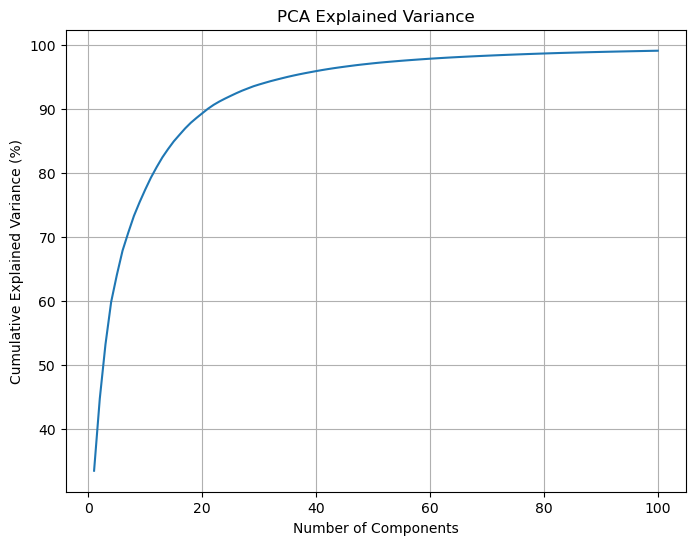

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(np.linspace(1, len(pca.explained_variance_ratio_), len(pca.explained_variance_ratio_)), np.cumsum(pca.explained_variance_ratio_)*100)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Explained Variance')
plt.grid()

In [ ]:
rec_test_prof = pca.inverse_transform(test_pca_prof).reshape(test_ssp_da.shape)

In [ ]:
rmse = np.sqrt(np.mean((rec_test_prof - test_ssp_da.data) ** 2))
print(f"RMSE between original and reconstructed test profiles: {rmse:.4f}")

RMSE between original and reconstructed test profiles: 0.5345
